<a href="https://colab.research.google.com/github/Bethel-boniface/Bethel-git/blob/main/wk1_project_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Diabetes Dataset Analysis

This project explores the Diabetes Dataset using Python, Pandas, and Exploratory Data Analysis (EDA).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# TASK 1 — AI Co-pilot Loop

## a) Explain the AI co-pilot loop

The AI co-pilot loop is a process where I work together with AI to generate and improve code.

The steps include:

1. Prompt the AI
2. Generate code
3. Run the code
4. Check errors or outputs
5. Fix or improve the code
6. Repeat the process until the solution works correctly

This workflow helps improve productivity and learning.

---

## b) Good AI Prompt Used This Week

### Prompt:
"Using pandas and seaborn, create charts that show the relationship between glucose levels and diabetes outcome."

### Why It Worked

The prompt worked well because it was clear, specific, and included:
- The tools to use
- The dataset context
- The expected result

In [7]:
df.isnull().sum()


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


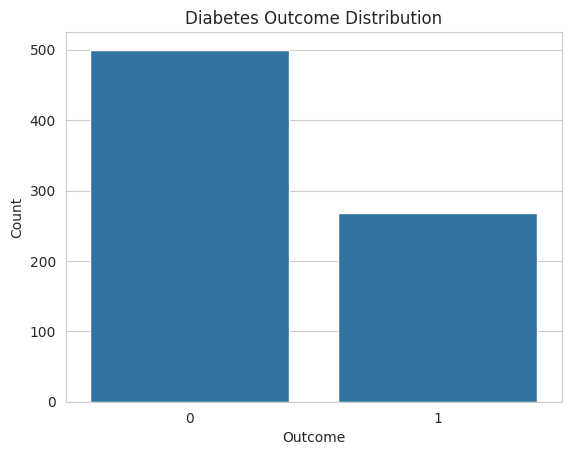

In [8]:
sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

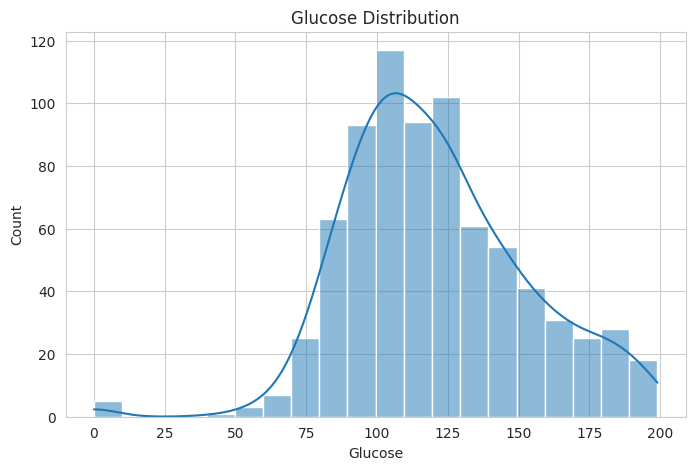

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Glucose"], bins=20, kde=True)

plt.title("Glucose Distribution")

plt.show()

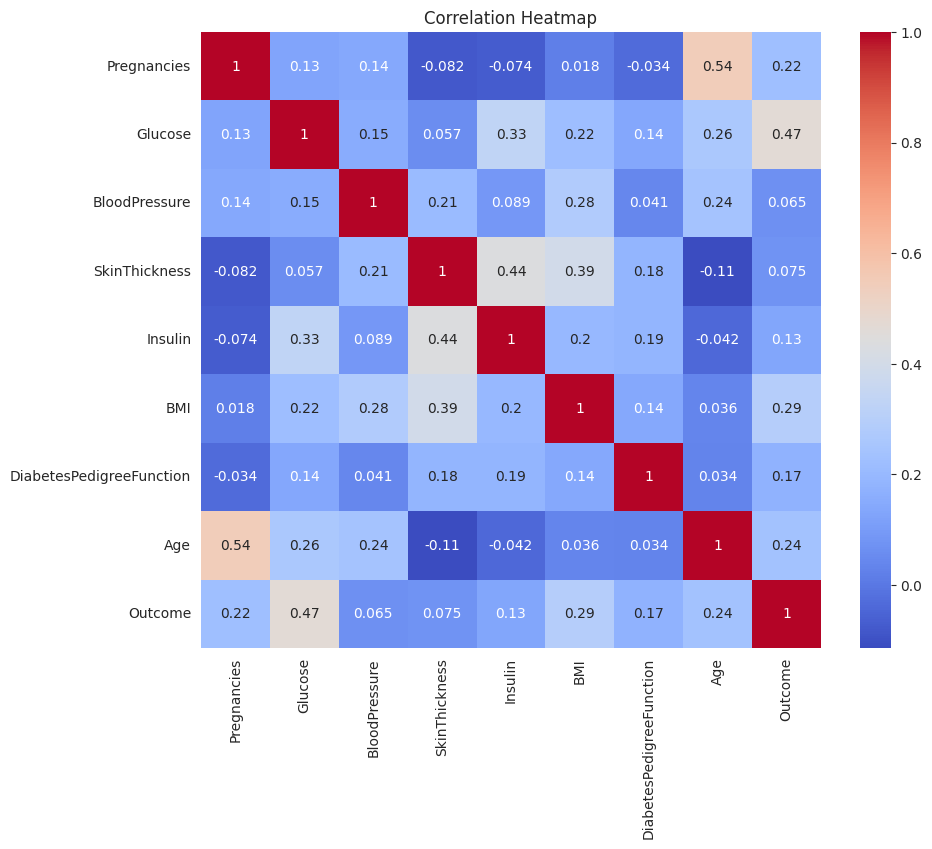

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Key Insights

1. Glucose has a strong relationship with diabetes outcome.
2. BMI is higher in many diabetic patients.
3. Age may influence diabetes risk.
4. Glucose and BMI are important indicators.

**TASK 2**


In [11]:
diabetes_count = df[df["Outcome"] == 1].shape[0]

print("Patients with diabetes:", diabetes_count)

Patients with diabetes: 268


The result makes sense because Outcome value 1 represents patients diagnosed with diabetes.

In [12]:
average_glucose = df["Glucose"].mean()

print("Average Glucose Level:", average_glucose)

Average Glucose Level: 120.89453125


This result makes sense because glucose levels vary among patients, and the mean gives the overall average level in the dataset.

In [13]:
female_above_40 = df[(df["Age"] > 40)]

print(female_above_40.head())

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
8             2      197             70             45      543  30.5   
9             8      125             96              0        0   0.0   
12           10      139             80              0        0  27.1   
13            1      189             60             23      846  30.1   

    DiabetesPedigreeFunction  Age  Outcome  
0                      0.627   50        1  
8                      0.158   53        1  
9                      0.232   54        1  
12                     1.441   57        0  
13                     0.398   59        1  


This result makes sense because filtering helps isolate a specific age group for further analysis.

In [14]:
average_bmi = df.groupby("Outcome")["BMI"].mean()

print(average_bmi)

Outcome
0    30.304200
1    35.142537
Name: BMI, dtype: float64


This result makes sense because BMI is often associated with diabetes risk and may differ between outcome groups.

In [15]:
original_rows = df.shape[0]

clean_df = df[df["Glucose"] != 0]

new_rows = clean_df.shape[0]

rows_removed = original_rows - new_rows

print("Rows removed:", rows_removed)

Rows removed: 5


This result makes sense because glucose values of zero are medically unrealistic and are treated as invalid data.

TASK 3

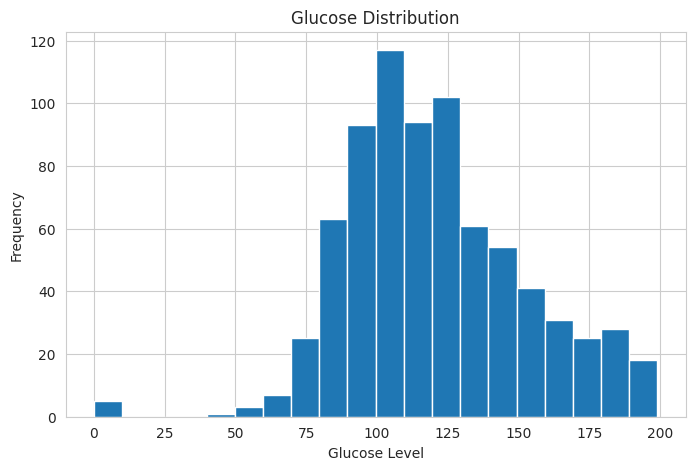

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df["Glucose"], bins=20)

plt.title("Glucose Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

plt.show()

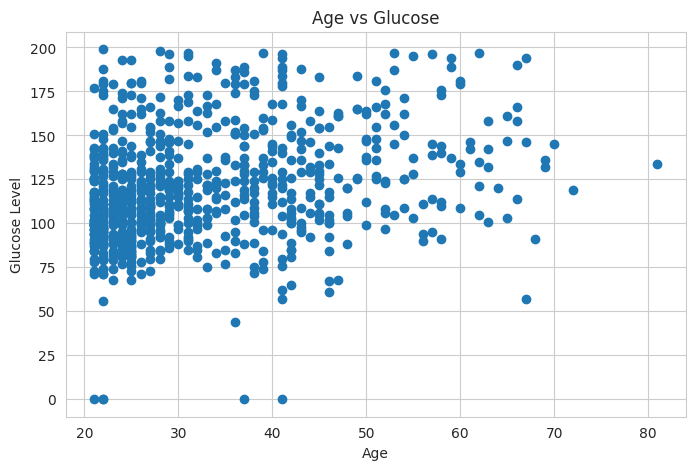

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Glucose"])

plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose Level")

plt.show()

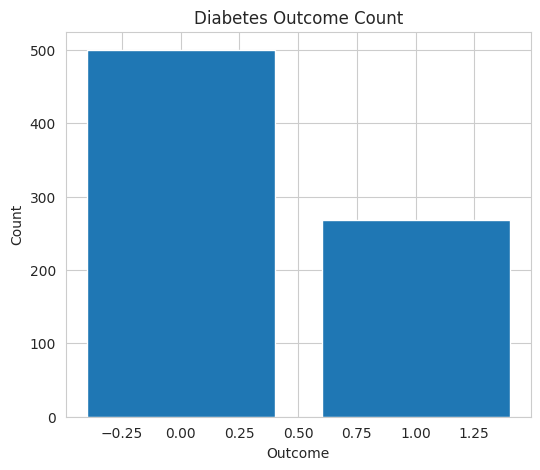

In [18]:
outcome_counts = df["Outcome"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(outcome_counts.index, outcome_counts.values)

plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

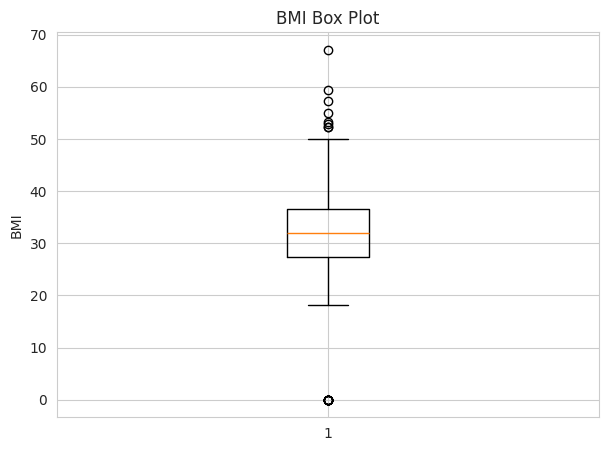

In [19]:
plt.figure(figsize=(7,5))

plt.boxplot(df["BMI"])

plt.title("BMI Box Plot")
plt.ylabel("BMI")

plt.show()

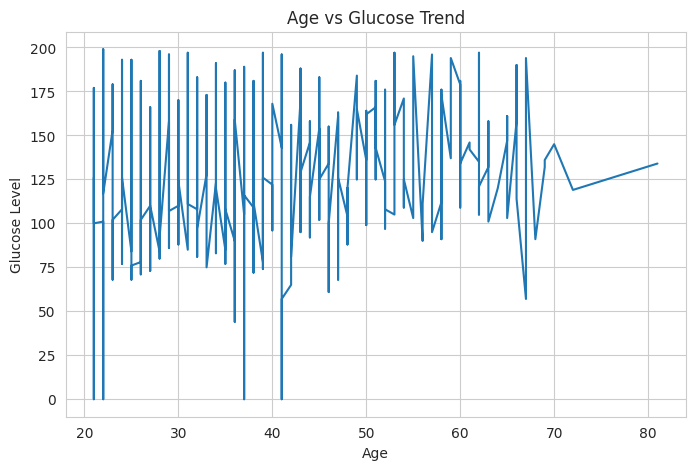

In [20]:
sorted_df = df.sort_values("Age")

plt.figure(figsize=(8,5))

plt.plot(sorted_df["Age"], sorted_df["Glucose"])

plt.title("Age vs Glucose Trend")
plt.xlabel("Age")
plt.ylabel("Glucose Level")

plt.show()

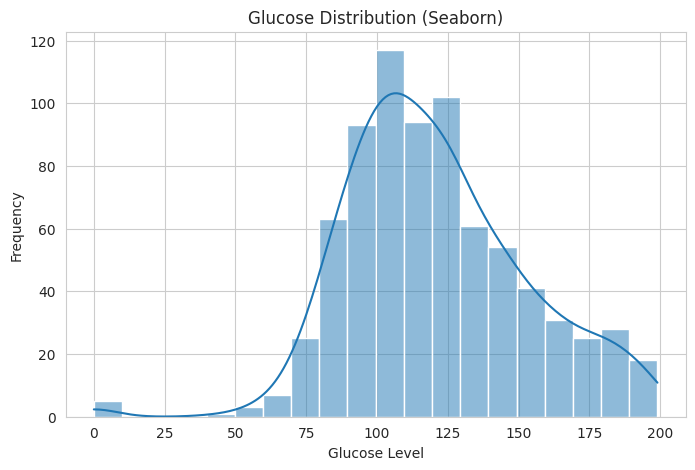

In [22]:
# Histogram with seaborn
plt.figure(figsize=(8,5))

sns.histplot(df["Glucose"], bins=20, kde=True)

plt.title("Glucose Distribution (Seaborn)")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")

plt.show()

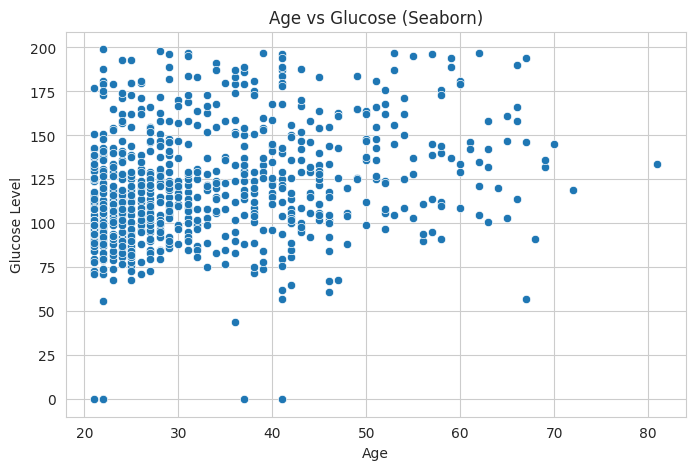

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Age", y="Glucose", data=df)

plt.title("Age vs Glucose (Seaborn)")
plt.xlabel("Age")
plt.ylabel("Glucose Level")

plt.show()

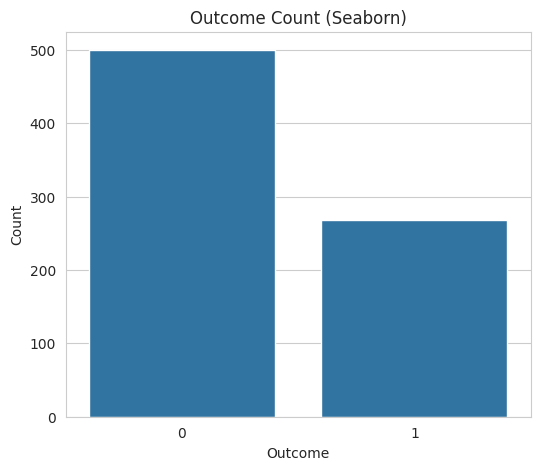

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(x="Outcome", data=df)

plt.title("Outcome Count (Seaborn)")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

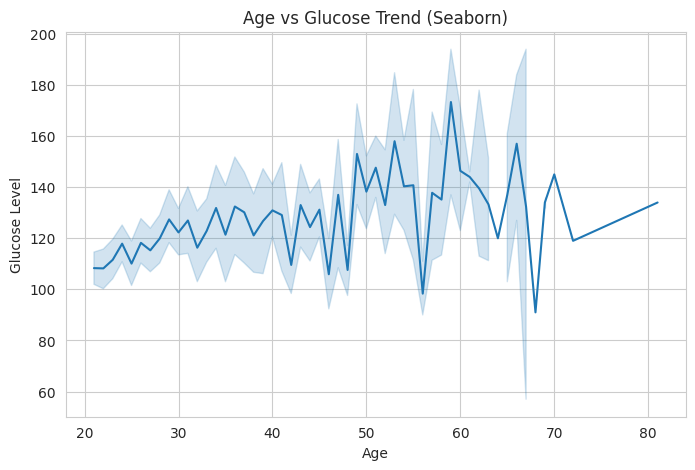

In [25]:
plt.figure(figsize=(8,5))

sns.lineplot(x=sorted_df["Age"], y=sorted_df["Glucose"])

plt.title("Age vs Glucose Trend (Seaborn)")
plt.xlabel("Age")
plt.ylabel("Glucose Level")

plt.show()

# Preferred Visualization Style

I prefer the seaborn charts because they are cleaner, more modern, and easier to read. The styling improves chart appearance and makes the data visualization more professional.

TASK 4

# Question 1

Does glucose level affect diabetes outcome?

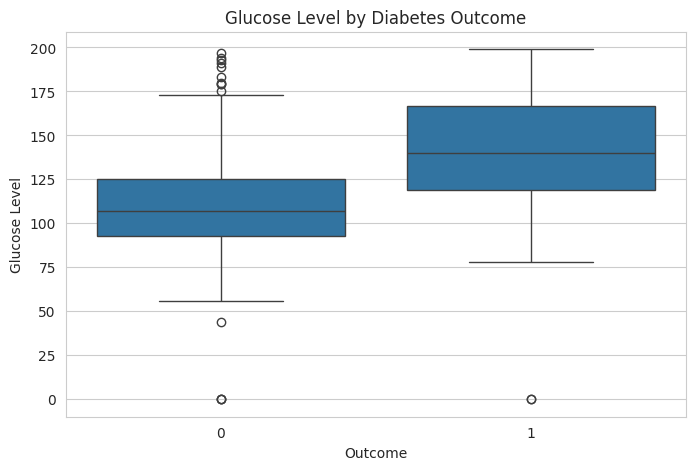

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="Glucose", data=df)

plt.title("Glucose Level by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose Level")

plt.show()

Patients with diabetes had higher glucose levels compared to non-diabetic patients.

# Question 2

Is BMI linked to diabetes outcome?

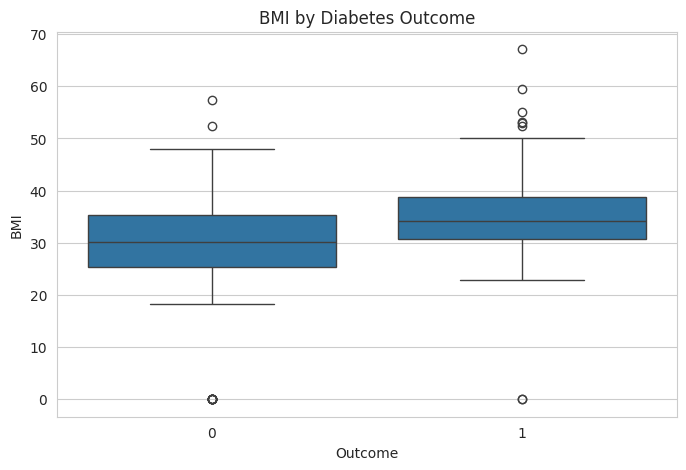

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

Patients with diabetes generally had higher BMI values than patients without diabetes.

# Question 3

Which age group has the highest diabetes rate?

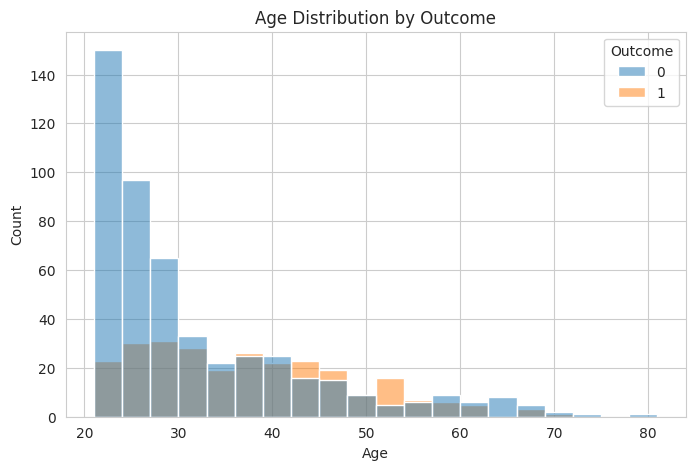

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", hue="Outcome", bins=20)

plt.title("Age Distribution by Outcome")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

Middle-aged patients appeared more frequently among diabetic cases in the dataset.

# What I Would Explore Next

I would further investigate how insulin levels and blood pressure affect diabetes risk. I would also explore combining this dataset with lifestyle or exercise datasets to better understand diabetes causes.

Additional features such as diet, physical activity, and family medical history would improve the analysis.

#Key takeaway

Patients with higher glucose levels and BMI were more likely to have diabetes.